# Group 77

## Assignment 2  Face Modification using VAE, β-VAE, VQ-VAE and GAN. Uses CelebA images.

|S.No| BITS ID | Name | Contribution |
|:-:| --- | --- | :---: |
|1| 2024AA05738 | Akshatha D | 100 |
|2| 2024AB05155| Dinesh Singh | 100 |
|3| 2024AA05181 | Jagadi Shruti Chanabasappa | 100 |
|4| 2024AA05534 | K Pranav Ram | 100 |
|5| 2024AA05748 | Kedar Ashutosh Anil | 100 |

In [67]:
import os
root = 'archive/img_align_celeba/img_align_celeba'
files = os.listdir(root)

print("Total images:", len(files))

Total images: 202599


# ========================
# Imports & Global Config
# ========================

In [68]:
import os
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 128
MAX_IMAGES = 48000
DATA_DIR = 'archive/img_align_celeba/img_align_celeba'
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def show_images(tensor, n=8, title=""):
    imgs = tensor[:n].detach().cpu().permute(0,2,3,1)
    plt.figure(figsize=(12,3))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(imgs[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()
print("Helper functions for visualization.")

Helper functions for visualization.


# ========================
# Dataset & Preprocessing
# ========================
Resize to 64x64, normalize to [0,1]

In [69]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, max_images=6000):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
        self.img_paths = self.img_paths[:max_images]
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor()  # Automatically scales to [0,1]
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert('RGB')
        img = self.transform(img)
        return img

In [70]:
dataset = CelebADataset(DATA_DIR, MAX_IMAGES)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print('Total images used:', len(dataset))

Total images used: 48000


# ========================
# Part A: Variational Autoencoder (VAE)
# ========================

In [71]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128*8*8, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*8*8, LATENT_DIM)
        self.fc_dec = nn.Linear(LATENT_DIM, 128*8*8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128,8,8)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        h_dec = self.fc_dec(z)
        x_recon = self.decoder(h_dec)
        return x_recon, mu, logvar, z

In [72]:
def vae_loss(x, x_recon, mu, logvar):
    recon = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl

In [73]:
vae = VAE().to(DEVICE)
opt_vae = optim.Adam(vae.parameters(), lr=1e-3)

In [74]:
# Train VAE
EPOCHS = 10
vae.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for x in tqdm(dataloader):
        x = x.to(DEVICE)
        x_recon, mu, logvar, _ = vae(x)
        loss = vae_loss(x, x_recon, mu, logvar)
        opt_vae.zero_grad()
        loss.backward()
        opt_vae.step()
        total_loss += loss.item()
    print(f'VAE Epoch {epoch+1}, Loss: {total_loss/len(dataset):.2f}')

100%|██████████| 750/750 [00:20<00:00, 36.45it/s]


VAE Epoch 1, Loss: 343.27


100%|██████████| 750/750 [00:11<00:00, 63.85it/s] 


VAE Epoch 2, Loss: 224.77


100%|██████████| 750/750 [00:13<00:00, 54.36it/s]


...

VAE Epoch 8, Loss: 195.61


100%|██████████| 750/750 [00:13<00:00, 57.16it/s] 


VAE Epoch 9, Loss: 194.30


100%|██████████| 750/750 [00:14<00:00, 52.08it/s]

VAE Epoch 10, Loss: 193.53


VAE Reconstructions

(np.float64(-0.5), np.float64(529.5), np.float64(133.5), np.float64(-0.5))

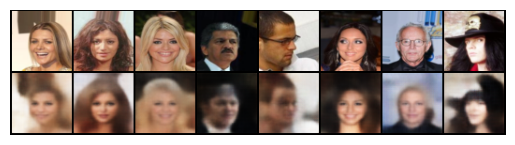

In [75]:
vae.eval()
x = next(iter(dataloader)).to(DEVICE)
x_recon, _, _, _ = vae(x)
grid = make_grid(torch.cat([x[:8], x_recon[:8]]), nrow=8)
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis('off')

VAE Latent Interpolation

In [76]:
z1 = vae.encoder(x[0:1]).view(1,-1)
z2 = vae.encoder(x[1:2]).view(1,-1)
mu1 = vae.fc_mu(z1)
mu2 = vae.fc_mu(z2)
interps = []
for a in torch.linspace(0,1,8):
    z = mu1*(1-a) + mu2*a
    img = vae.decoder(vae.fc_dec(z))
    interps.append(img)
interp_grid = make_grid(torch.cat(interps), nrow=8)

VAE Input shape: torch.Size([64, 3, 64, 64])
VAE Recon shape: torch.Size([64, 3, 64, 64])
VAE Mu shape: torch.Size([64, 128])
VAE LogVar shape: torch.Size([64, 128])


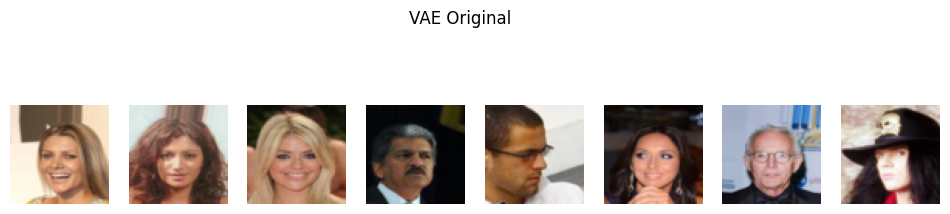

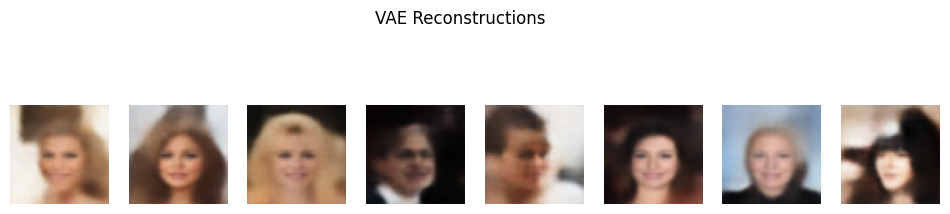

In [77]:
# ===== Part A: VAE Debug & Results =====
vae.eval()
with torch.no_grad():
    out = vae(x)

# Handle variable number of outputs safely
xr = out[0]
mu = out[1]
logvar = out[2]

print("VAE Input shape:", x.shape)
print("VAE Recon shape:", xr.shape)
print("VAE Mu shape:", mu.shape)
print("VAE LogVar shape:", logvar.shape)

show_images(x, title="VAE Original")
show_images(xr, title="VAE Reconstructions")



# ========================
# Part B: β-VAE
# ========================

In [78]:
def beta_vae_loss(x, x_recon, mu, logvar, beta):
    recon = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl

In [79]:
betas = [2,4,10]
beta_models = {}

for beta in betas:
    print(f'Training β-VAE with beta={beta}')
    model = VAE().to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(10):
        for x in tqdm(dataloader):
            x = x.to(DEVICE)
            xr, mu, logvar, _ = model(x)
            loss = beta_vae_loss(x, xr, mu, logvar, beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
    beta_models[beta] = model

Training β-VAE with beta=2


100%|██████████| 750/750 [00:13<00:00, 56.21it/s]


Training β-VAE with beta=4


100%|██████████| 750/750 [00:13<00:00, 54.13it/s]


Training β-VAE with beta=10


100%|██████████| 750/750 [00:11<00:00, 62.80it/s] 


Latent Traversal (Disentanglement Visualization)

In [80]:
beta = 4
model = beta_models[beta]
model.eval()
x = next(iter(dataloader)).to(DEVICE)
_, mu, _, _ = model(x[:1])
traversals = []
for dim in range(8):
    for val in torch.linspace(-3,3,6):
        z = mu.clone()
        z[0,dim] = val
        img = model.decoder(model.fc_dec(z))
        traversals.append(img)
trav_grid = make_grid(torch.cat(traversals), nrow=6)

Beta-VAE (beta=2) Recon shape: torch.Size([64, 3, 64, 64])
Beta-VAE (beta=2) Mu shape: torch.Size([64, 128])
Beta-VAE (beta=2) LogVar shape: torch.Size([64, 128])


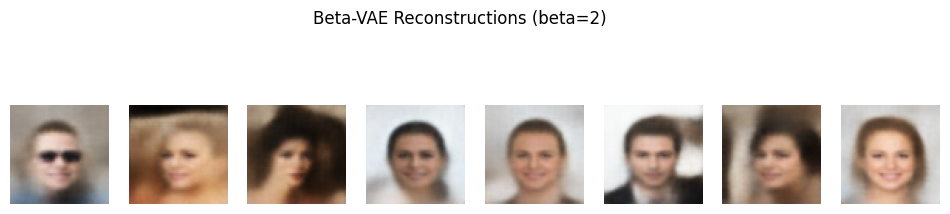

Beta-VAE (beta=4) Recon shape: torch.Size([64, 3, 64, 64])
Beta-VAE (beta=4) Mu shape: torch.Size([64, 128])
Beta-VAE (beta=4) LogVar shape: torch.Size([64, 128])


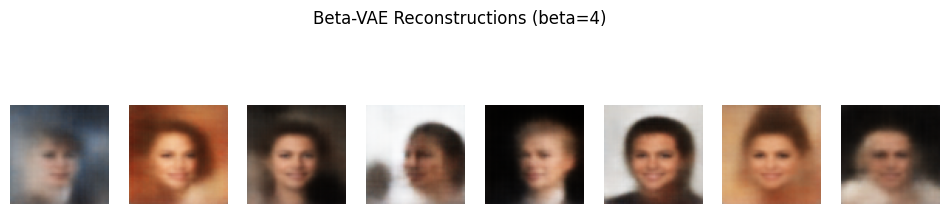

Beta-VAE (beta=10) Recon shape: torch.Size([64, 3, 64, 64])
Beta-VAE (beta=10) Mu shape: torch.Size([64, 128])
Beta-VAE (beta=10) LogVar shape: torch.Size([64, 128])


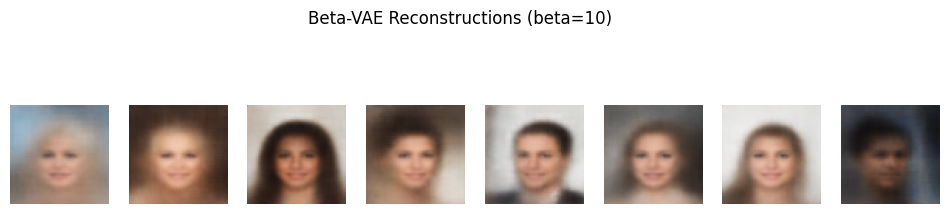

In [81]:

# ===== Part B: Beta-VAE Debug & Results =====
# Uses beta_models dict created during training

for beta, model in beta_models.items():
    model.eval()
    with torch.no_grad():
        x = next(iter(dataloader)).to(DEVICE)
        out = model(x)

    xr = out[0]
    mu = out[1]
    logvar = out[2]

    print(f"Beta-VAE (beta={beta}) Recon shape:", xr.shape)
    print(f"Beta-VAE (beta={beta}) Mu shape:", mu.shape)
    print(f"Beta-VAE (beta={beta}) LogVar shape:", logvar.shape)

    show_images(xr, title=f"Beta-VAE Reconstructions (beta={beta})")


# ========================
# Part C: VQ-VAE + PixelCNN Prior
# ========================
Proper discrete latents + PixelCNN prior over codes

In [82]:

import torch.nn.functional as F
# -------- Vector Quantizer for VQ-VAE --------
class VectorQuantizer(nn.Module):
    def __init__(self, K, D, beta=0.25):
        super().__init__()
        self.K = K
        self.D = D
        self.beta = beta
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1.0/K, 1.0/K)
        self.vq_loss = torch.tensor(0.0)  # updated each forward()

    def forward(self, z):
        # z: (B, H, W, D)
        flat_z = z.reshape(-1, self.D)  # (B*H*W, D)

        # Compute distances to embeddings
        dist = (
            torch.sum(flat_z**2, dim=1, keepdim=True)
            + torch.sum(self.embedding.weight**2, dim=1).unsqueeze(0)
            - 2 * torch.matmul(flat_z, self.embedding.weight.t())
        )  # (N, K)

        # Get encoding indices
        idx = torch.argmin(dist, dim=1)  # (B*H*W,)
        z_q = self.embedding(idx).view(z.shape)  # (B,H,W,D)

        # VQ Losses (IMPORTANT)
        # - Codebook loss updates embedding vectors
        # - Commitment loss encourages encoder outputs to stick to codes
        codebook_loss = F.mse_loss(z_q, z.detach())
        commit_loss   = F.mse_loss(z, z_q.detach())
        self.vq_loss  = codebook_loss + self.beta * commit_loss

        # Straight-through estimator (gradient to encoder, not to embedding here)
        z_q_st = z + (z_q - z).detach()

        idx = idx.view(z.shape[0], z.shape[1], z.shape[2]).long()
        return z_q_st, idx


In [83]:
# -------- VQ-VAE Encoder / Decoder --------
class VQVAE(nn.Module):
    def __init__(self, K=512, D=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, D, 1)
        )
        self.vq = VectorQuantizer(K, D)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(D, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 3, 1), nn.Sigmoid()
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_e_perm = z_e.permute(0,2,3,1)
        z_q, idx = self.vq(z_e_perm)
        z_q = z_q.permute(0,3,1,2)
        x_recon = self.decoder(z_q)
        return x_recon, z_e, z_q, idx

In [91]:
vqvae = VQVAE(K=512, D=128).to(DEVICE)
opt_vq = optim.Adam(vqvae.parameters(), lr=2e-4)

In [92]:
# Train VQ-VAE
for epoch in range(20):
    vqvae.train()
    for x in tqdm(dataloader):
        x = x.to(DEVICE)

        xr, z_e, z_q, _ = vqvae(x)

        recon = nn.functional.mse_loss(xr, x)
        vq_loss = vqvae.vq.vq_loss  # set during forward()

        loss = recon + vq_loss

        opt_vq.zero_grad()
        loss.backward()
        opt_vq.step()

    print(f'VQ-VAE Epoch {epoch+1}, Recon Loss: {recon.item():.4f}, VQ Loss: {vq_loss.item():.4f}')

100%|██████████| 750/750 [00:14<00:00, 51.20it/s] 


VQ-VAE Epoch 1, Recon Loss: 0.0092, VQ Loss: 0.0427


100%|██████████| 750/750 [00:15<00:00, 47.51it/s]


VQ-VAE Epoch 2, Recon Loss: 0.0055, VQ Loss: 0.0074


100%|██████████| 750/750 [00:14<00:00, 52.26it/s] 


...

VQ-VAE Epoch 18, Recon Loss: 0.0034, VQ Loss: 0.0091


100%|██████████| 750/750 [00:15<00:00, 49.37it/s]


VQ-VAE Epoch 19, Recon Loss: 0.0029, VQ Loss: 0.0073


100%|██████████| 750/750 [00:13<00:00, 54.51it/s] 

VQ-VAE Epoch 20, Recon Loss: 0.0033, VQ Loss: 0.0082


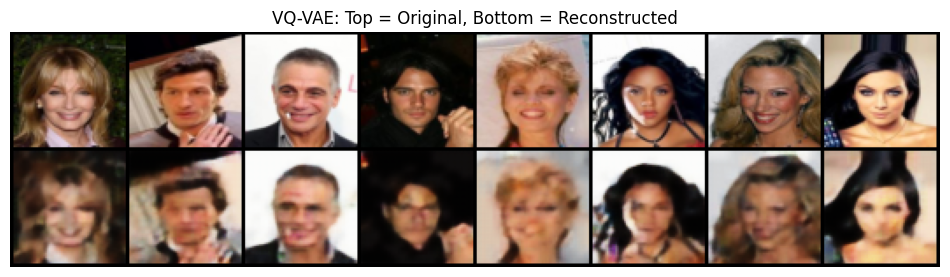

In [93]:
# Save VQ-VAE reconstructions
vqvae.eval()
with torch.no_grad():
    x = next(iter(dataloader)).to(DEVICE)
    xr, _, _, _ = vqvae(x)

grid = make_grid(torch.cat([x[:8], xr[:8]]), nrow=8)
img = grid.detach().cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 4))
plt.imshow(img)
plt.axis("off")
plt.title("VQ-VAE: Top = Original, Bottom = Reconstructed")
plt.show()


In [94]:
# -------- PixelCNN Prior (Masked) --------
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ["A", "B"]
        self.mask_type = mask_type
        self.register_buffer("mask", torch.ones_like(self.weight))

        _, _, kH, kW = self.weight.shape
        yc, xc = kH // 2, kW // 2

        # mask out "future" pixels
        self.mask[:, :, yc+1:, :] = 0
        self.mask[:, :, yc, xc+1:] = 0
        if mask_type == "A":
            self.mask[:, :, yc, xc] = 0  # also mask current pixel

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)


class PixelCNN(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.K = K

        # keep your embedding
        self.emb = nn.Embedding(K, 64)

        # masked conv stack (+2 extra layers)
        self.net = nn.Sequential(
            MaskedConv2d("A", 64, 128, 7, padding=3), nn.ReLU(),

            MaskedConv2d("B", 128, 128, 3, padding=1), nn.ReLU(),
            MaskedConv2d("B", 128, 128, 3, padding=1), nn.ReLU(),

            # --- extra layers (2 more) ---
            MaskedConv2d("B", 128, 128, 3, padding=1), nn.ReLU(),
            MaskedConv2d("B", 128, 128, 3, padding=1), nn.ReLU(),
            # -----------------------------

            nn.Conv2d(128, K, 1)  # logits (B, K, H, W)
        )

    def forward(self, x):
        # x: (B, H, W) long
        x = self.emb(x).permute(0, 3, 1, 2).contiguous()  # (B,64,H,W)
        x = self.net(x)                                   # (B,K,H,W)
        return x

In [ ]:
pixelcnn = PixelCNN(K=512).to(DEVICE)
opt_pc = optim.Adam(pixelcnn.parameters(), lr=5e-4)

In [96]:
# Extract discrete latents for training PixelCNN
latent_maps = []
with torch.no_grad():
    for x in tqdm(dataloader):
        x = x.to(DEVICE)
        _, _, _, idx = vqvae(x)
        latent_maps.append(idx.cpu())
latent_maps = torch.cat(latent_maps)

100%|██████████| 750/750 [00:14<00:00, 51.95it/s]


In [97]:
# Train PixelCNN
for epoch in range(40):
    for i in tqdm(range(0, latent_maps.size(0), BATCH_SIZE)):
        batch = latent_maps[i:i+BATCH_SIZE].to(DEVICE)
        logits = pixelcnn(batch)
        loss = nn.functional.cross_entropy(logits, batch)
        opt_pc.zero_grad(); loss.backward(); opt_pc.step()
    print(f'PixelCNN Epoch {epoch+1}, Loss: {loss.item():.4f}')

100%|██████████| 750/750 [00:11<00:00, 63.14it/s]


PixelCNN Epoch 1, Loss: 2.5626


100%|██████████| 750/750 [00:10<00:00, 72.27it/s] 


PixelCNN Epoch 2, Loss: 2.4483


100%|██████████| 750/750 [00:11<00:00, 62.54it/s]


...

PixelCNN Epoch 38, Loss: 2.1295


100%|██████████| 750/750 [00:10<00:00, 69.90it/s]


PixelCNN Epoch 39, Loss: 2.1286


100%|██████████| 750/750 [00:10<00:00, 68.82it/s]

PixelCNN Epoch 40, Loss: 2.1277


In [98]:
@torch.no_grad()
def pixelcnn_sample(pixelcnn, H, W, n=1, temperature=1.0):
    pixelcnn.eval()
    x_idx = torch.zeros(n, H, W, dtype=torch.long, device=DEVICE)

    for i in range(H):
        for j in range(W):
            logits = pixelcnn(x_idx)                           # (n, K, H, W)
            logits_ij = logits[:, :, i, j] / max(temperature, 1e-6)
            probs = torch.softmax(logits_ij, dim=1)            # (n, K)
            x_idx[:, i, j] = torch.multinomial(probs, 1).squeeze(1)

    return x_idx

H, W = latent_maps.shape[1], latent_maps.shape[2]
sampled = pixelcnn_sample(pixelcnn, H, W, n=16, temperature=1.0)
print("sampled shape:", sampled.shape, "unique codes sample0:", sampled[0].unique().numel())

sampled shape: torch.Size([16, 16, 16]) unique codes sample0: 48


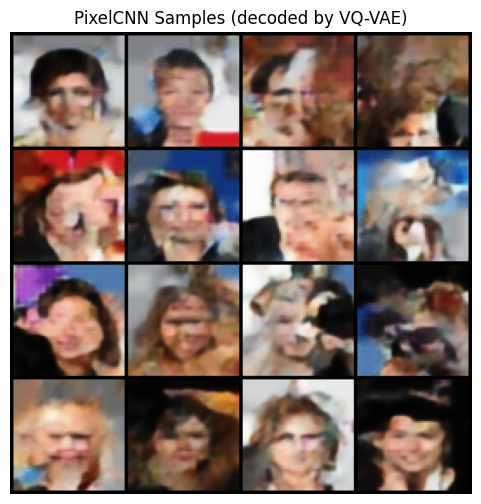

In [99]:
# Decode sampled latents to images
vqvae.eval()
with torch.no_grad():
    # sampled: (N, H, W)
    z_q = vqvae.vq.embedding(sampled)                 # (N, H, W, D)
    z_q = z_q.permute(0, 3, 1, 2).contiguous()        # (N, D, H, W)
    fake_faces = vqvae.decoder(z_q)                   # (N, 3, 64, 64)

grid = make_grid(fake_faces.cpu(), nrow=4, padding=2)
img = grid.permute(1, 2, 0).numpy()  # CHW -> HWC

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("PixelCNN Samples (decoded by VQ-VAE)")
plt.show()

VQ-VAE model: VQVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (vq): VectorQuantizer(
    (embedding): Embedding(512, 128)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 3, kernel_size=(1, 1), stride=(1, 1))
    (5): Sigmoid()
  )
)
Input batch shape: torch.Size([64, 3, 64, 64])
Reconstruction shape: torch.Size([64, 3, 64, 64])
Latent z_e shape: torch.Size([64, 128, 16, 16])
Latent z_q shape: torch.Size([64, 128, 16, 16])
Discrete latent idx shape: torch.Size([64, 16, 16])


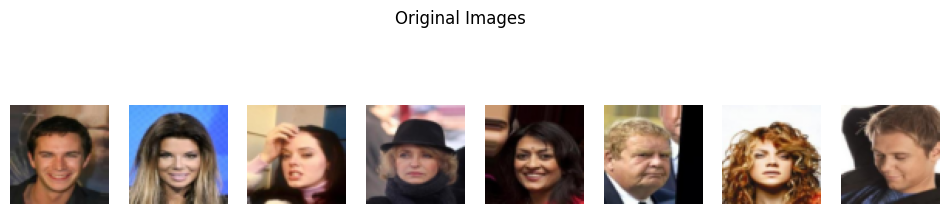

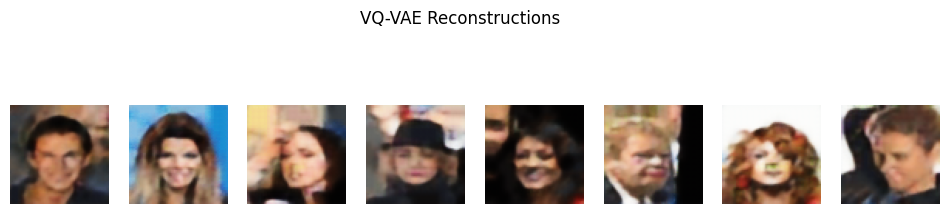

In [100]:

# ===== Part C Debug & Visualization =====
print("VQ-VAE model:", vqvae)
# Show VQ-VAE Reconstructions
vqvae.eval()
with torch.no_grad():
    x = next(iter(dataloader)).to(DEVICE)
    xr, z_e, z_q, idx = vqvae(x)

print("Input batch shape:", x.shape)
print("Reconstruction shape:", xr.shape)
print("Latent z_e shape:", z_e.shape)
print("Latent z_q shape:", z_q.shape)
print("Discrete latent idx shape:", idx.shape)

show_images(x, title="Original Images")
show_images(xr, title="VQ-VAE Reconstructions")

# ========================
# Part D: GAN
# ========================

In [102]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 512), nn.ReLU(),
            nn.Linear(512, 3*64*64), nn.Sigmoid()
        )
    def forward(self, z):
        x = self.net(z)
        return x.view(-1,3,64,64)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*64*64, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

In [104]:
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
optG = optim.Adam(G.parameters(), lr=2e-4)
optD = optim.Adam(D.parameters(), lr=2e-4)
bce = nn.BCELoss()

In [106]:
# Train GAN
for epoch in range(10):
    for real in tqdm(dataloader):
        real = real.to(DEVICE)
        bs = real.size(0)
        z = torch.randn(bs,128).to(DEVICE)
        fake = G(z)

        # Train D
        lossD = bce(D(real), torch.ones(bs,1).to(DEVICE)) + \
                bce(D(fake.detach()), torch.zeros(bs,1).to(DEVICE))
        optD.zero_grad(); lossD.backward(); optD.step()

        # Train G
        lossG = bce(D(fake), torch.ones(bs,1).to(DEVICE))
        optG.zero_grad(); lossG.backward(); optG.step()

100%|██████████| 750/750 [00:13<00:00, 55.61it/s]


GAN Samples

GAN Generated batch shape: torch.Size([8, 3, 64, 64])


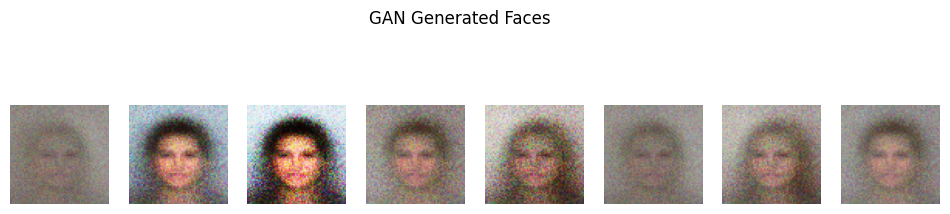

In [ ]:
# ===== Part D: GAN Debug & Results =====
G.eval()
with torch.no_grad():
    z = torch.randn(8, 128).to(DEVICE)   
    fake = G(z)

print("GAN Generated batch shape:", fake.shape)
show_images(fake, title="GAN Generated Faces")


# ========================
# Part E: Comparative Analysis
# ========================

## Comparative Analysis
### 1.Reconstruction Quality
  - VAE produces smooth but slightly blurry reconstructions due to Gaussian latent space.

  - β-VAE shows degraded reconstruction quality as β increases, due to stronger KL regularization.

  - VQ-VAE achieves sharper reconstructions than VAE because of discrete latent representations.

  - GAN does not reconstruct input images, but generates sharp and realistic samples.

### 2. Disentanglement & Interpretability

  - β-VAE shows the best disentanglement. Latent traversals reveal individual dimensions controlling attributes such as:

    - Smile

    - Head pose

    - Gender-related features

  - Standard VAE has entangled latent dimensions.

  - VQ-VAE latents are discrete and less interpretable dimension-wise.

  - GAN latent space is difficult to interpret semantically.

### 3. Attribute Manipulation

  - VAE / β-VAE support vector arithmetic for attribute modification (e.g., smile vectors).

  - β-VAE shows cleaner attribute changes with fewer side effects.

  - VQ-VAE does not naturally support continuous attribute vector arithmetic.

  - GAN latent interpolation produces smooth visual transitions but attribute control is indirect.

### 4. Sample Realism

  - GAN produces the most realistic and sharp face images.

  - VQ-VAE + PixelCNN produces realistic but sometimes repetitive samples due to discrete codes.

  - VAE / β-VAE samples are blurrier and less detailed.

### 5. Latent Space Structure

  - VAE: Continuous but entangled latent space.

  - β-VAE: Continuous and more disentangled latent space.

  - VQ-VAE: Discrete latent space with learned codebook.

  - GAN: Implicit latent space optimized for realism, not reconstruction.